
# Practical 16: Vision Transformers (ViT) on Flowers (5 Classes)


## Learning Goals
By the end of this practical you will be able to:
1. Explain the **original Transformer** idea (queries, keys, values, and self-attention).
2. Describe how **Vision Transformer (ViT)** adapts Transformers to images (patch embedding, class token, positional encoding).
3. Contrast **CNNs vs ViTs** — what each is good/bad at, and why.
4. **Fine-tune** a pretrained ViT on a **5-class flowers dataset** (daisy, dandelion, rose, sunflower, tulip).
5. Evaluate with accuracy & confusion matrix; read off **common failure modes**.

> Roadmap connection: This practical follows the previous CNN-based practicals (AlexNet → VGG → Inception → ResNet → MobileNet → DenseNet → EfficientNet → Transfer Learning). Here we take the next step: **attention-based** vision models.

---


## 0) Recap & Dataset 
- In earlier practicals we resized images to a **fixed size** for CNNs.
- **ViT with ImageNet pretrained weights expects 224 × 224** images.
- Our flowers images are already **224 × 224**, so they directly match ViT.
  We still apply a `Resize((224, 224))` transform to be explicit and consistent.
- Download the **flowers dataset** from my Google Drive: [Flowers Dataset Link](https://drive.google.com/file/d/1Oaghg3cBXOD88LAfa5pWXzuHtiJ93o7O/view?usp=sharing)

If you already have `train/val/test` folders, the loader will detect and use them. If not, we’ll **auto-split** into train/val/test with a fixed random seed for reproducibility.



## 1) From the Original Transformer (NLP) to ViT (Vision)

### 1.1 The Transformer in 4 lines
- **Inputs become vectors** (embeddings).
- For each token (word), we form **Query (Q)**, **Key (K)**, **Value (V)** via linear projections of the embedding.
- **Self‑Attention (scaled dot‑product)** — compute scores \(S\), normalize to attention weights \(A\), then mix values:

$$
S \;=\; \frac{QK^\top}{\sqrt{d_k}}, \qquad A \;=\; \operatorname{softmax}(S)
$$

$$
\operatorname{Attention}(Q,K,V) \;=\; A\,V \;=\; \operatorname{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

*Softmax is applied row‑wise over keys. Typical shapes:
$$
Q,K \in \mathbb{R}^{N\times d_k},\ V\in\mathbb{R}^{N\times d_v}.
$$
- **Multi‑Head Attention** = several attentions in parallel, concatenate, then a small MLP. Stacking layers yields deep modeling of relationships.

> **Need an even easier, visual explanation?**  
> Explore **TRANSFORMER EXPLAINER** (interactive): **https://poloclub.github.io/transformer-explainer/**  
> Use it to see how *self‑attention* and *multi‑head attention* work step‑by‑step.


### 1.2 Turning images into tokens: ViT
- **Split the image into patches** (e.g., 16×16). A 224×224 image gives \( (224/16)^2 = 14 * 14 = 196 \) patches.
- **Flatten each patch** and pass through a **linear layer** → a sequence of patch embeddings (tokens).
- Add a special **[CLS] token** (classification token).
- Add **positional embeddings** so the model knows patch order/position.
- Feed the sequence to a standard **Transformer encoder**.
- Use the final **[CLS]** representation for classification.

### 1.3 Why ViT can shine
- **Global self‑attention**: every patch can directly attend to every other patch → great for **long‑range dependencies** and **global context**.
- **Flexible inductive biases**: ViT is less constrained than CNNs; it learns what locality/structure is useful from data.

### 1.4 CNNs vs ViT (quick comparison)
| Aspect | CNN | ViT |
|---|---|---|
| Inductive bias | Strong (locality, translation equivariance) | Weaker (learned from data) |
| Data efficiency | Often better on **small datasets** | Shines with **more data** (or good pretraining) |
| Receptive field | Grows with depth; local by design | **Global** via attention in every layer |
| Complexity | Scales linearly with pixels per layer | **O(N²)** with number of patches (N) |
| Interpretability | Feature maps/filters | **Attention maps** (intuitive but nuanced) |

> Teaching tip: CNNs are great “starter models” (inductive bias = helpful rules). ViT is more “general” but needs more data or transfer learning.


<center>
<img src="images/vit.png" alt="ViT" width="700"/>
</center>


### 1.5 CNN inductive biases: strengths *and* limitations (what ViT changes)
- **Locality (local receptive fields)**  
  - *Strength:* Early layers focus on small neighborhoods → efficient edge/texture detectors.  
  - *Limitation:* Long-range relationships require stacking many layers to grow the receptive field; **global context** can be harder to capture. ViT uses **self‑attention** to connect distant patches directly.
- **Translation equivariance / invariance**  
  - *Strength:* Convolutions (plus pooling) make features robust to shifts → good generalization when objects move in the image.  
  - *Limitation:* This bias assumes statistics are similar across locations; detailed **absolute position** information can be blurred. ViT keeps **positional embeddings**, so it can learn when absolute position matters.
- **Weight sharing**  
  - *Strength:* The same filter slides everywhere → far fewer parameters and strong regularization.  
  - *Limitation:* Imposes a **stationarity assumption** (“the same pattern looks the same everywhere”), which can be suboptimal when context varies strongly. ViT’s attention weights are **content‑dependent** and can adapt interactions patch‑by‑patch.



## 2) Setup
We’ll use **PyTorch** and **torchvision**’s `vit_b_16` with ImageNet weights, and fine-tune the classification head for 5 classes.


In [1]:

# 2.1 Imports and global config
import os, random, time, copy, math
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms, datasets
from torchvision.models import vit_b_16, ViT_B_16_Weights

import numpy as np

# Optional: metrics & confusion matrix
try:
    from sklearn.metrics import classification_report, confusion_matrix
    SKLEARN_OK = True
except Exception:
    SKLEARN_OK = False

# Fix seeds for reproducibility (important for students)
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE


device(type='cuda')


## 3) Data: Loading the 5-Class Flowers Dataset
We’ll use `ImageFolder` for simplicity.  
**Transforms** (kept gentle for undergrads):
- Train: resize → **224×224**, light augmentation (flip, rotation, color jitter), normalize (ImageNet stats).
- Val/Test: resize → **224×224**, normalize (ImageNet stats).

> We **resize to 224×224** to match the pretrained ViT’s positional embeddings.


In [6]:

# 3.1 Paths & transforms
DATA_ROOT = Path("flowers")  # <-- change if your path differs

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224  # Pretrained ViT default

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# 3.2 Helper: build (train/val/test) either from existing folders or auto-split
def build_datasets(root: Path, val_ratio=0.15, test_ratio=0.15, seed=42):
    """
    If root contains 'train','val','test' subfolders -> load directly.
    Else: auto-split a single ImageFolder in root into train/val/test.
    """
    set_seed(seed)
    train_dir, val_dir, test_dir = root/'train', root/'val', root/'test'
    if train_dir.exists() and val_dir.exists() and test_dir.exists():
        train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
        val_ds   = datasets.ImageFolder(val_dir, transform=eval_tfms)
        test_ds  = datasets.ImageFolder(test_dir, transform=eval_tfms)
        return train_ds, val_ds, test_ds

    # Auto-split case
    full_ds = datasets.ImageFolder(root, transform=None)  # raw first
    n_total = len(full_ds)
    n_test  = int(test_ratio * n_total)
    n_val   = int(val_ratio * n_total)
    n_train = n_total - n_val - n_test

    train_raw, val_raw, test_raw = random_split(
        full_ds, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(seed)
    )

    # Wrap raw subsets with transform
    class SubsetWithTransform(torch.utils.data.Dataset):
        def __init__(self, subset, transform):
            self.subset = subset
            self.transform = transform
            self.classes = subset.dataset.classes
            self.class_to_idx = subset.dataset.class_to_idx
        def __len__(self): return len(self.subset)
        def __getitem__(self, idx):
            x, y = self.subset[idx]
            return self.transform(x), y

    train_ds = SubsetWithTransform(train_raw, train_tfms)
    val_ds   = SubsetWithTransform(val_raw, eval_tfms)
    test_ds  = SubsetWithTransform(test_raw, eval_tfms)
    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = build_datasets(DATA_ROOT)

CLASS_NAMES = getattr(train_ds, "classes", None) or getattr(train_ds.subset.dataset, "classes", [])
NUM_CLASSES = len(CLASS_NAMES) if CLASS_NAMES else 5
print(f"Classes: {CLASS_NAMES} (n={NUM_CLASSES})")
print(f"Sizes -> train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")

# 3.3 DataLoaders
BATCH_SIZE = 100
NUM_WORKERS = 1 

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

len(train_loader), len(val_loader), len(test_loader)


Classes: ['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip'] (n=5)
Sizes -> train: 4008, val: 500, test: 500


(41, 5, 5)


### 3.4 Visualize a batch


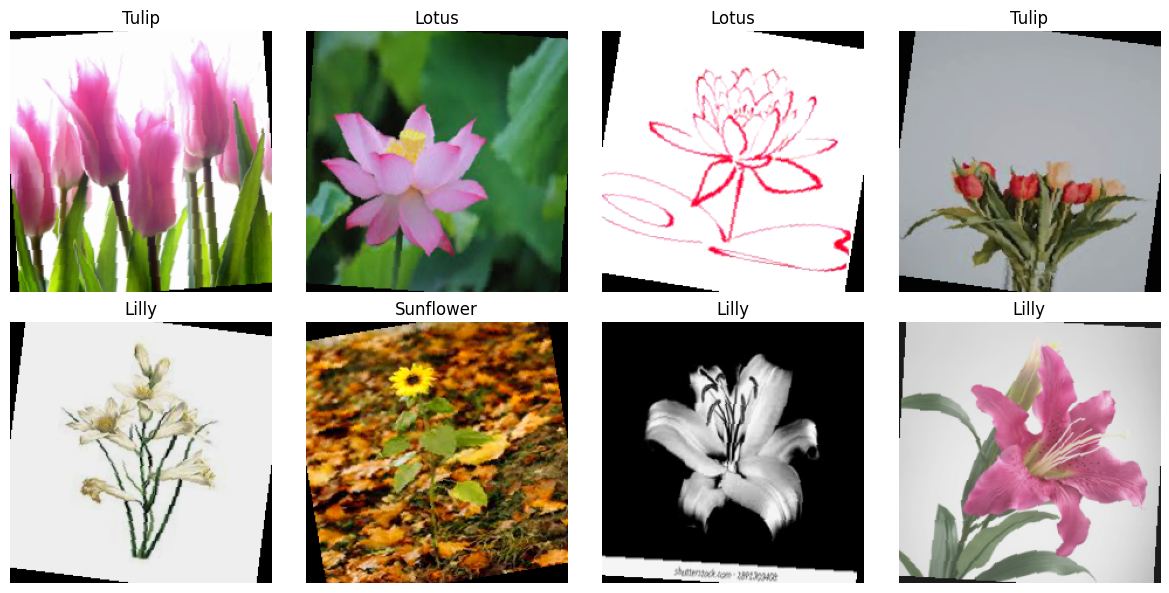

In [3]:

import matplotlib.pyplot as plt
import itertools

def show_batch(dataloader, classes, max_images=8):
    images, labels = next(iter(dataloader))
    images = images[:max_images]
    labels = labels[:max_images]
    # Undo normalization for display
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    imgs = images * std + mean

    n = len(imgs)
    cols = min(n, 4)
    rows = math.ceil(n/cols)
    plt.figure(figsize=(3*cols, 3*rows))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        img = imgs[i].permute(1,2,0).cpu().numpy()
        plt.imshow(np.clip(img, 0, 1))
        title = classes[labels[i]] if classes else str(labels[i].item())
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_loader, CLASS_NAMES)



## 4) Model: ViT-B/16 (Pretrained) → 5 classes
We load a **pretrained ViT-B/16** (patch size = 16) and replace the classification head for 5 classes.
- Option A (default): **Fine-tune all layers** (works well on medium datasets).  
- Option B: **Freeze backbone** and train only the head (faster, less risk of overfitting with tiny datasets). 

In [4]:

# 4.1 Create the model
weights = ViT_B_16_Weights.IMAGENET1K_V1
model = vit_b_16(weights=weights)
in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, NUM_CLASSES)

FREEZE_BACKBONE = False  # set True to train only the new head

if FREEZE_BACKBONE:
    for name, param in model.named_parameters():
        if not name.startswith("heads"):
            param.requires_grad = False

model = model.to(DEVICE)

# 4.2 Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss()
# AdamW is standard for Transformers
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-5, weight_decay=0.01)
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

# Mixed precision speeds up training on GPU
USE_AMP = True if DEVICE.type == "cuda" else False

sum(p.numel() for p in model.parameters() if p.requires_grad), sum(p.numel() for p in model.parameters())


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\dell/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth
100.0%


(85802501, 85802501)


## 5) Training Loop (with validation)
We’ll train for a few epochs and keep track of the **best validation accuracy** to save the best weights.


In [8]:

def train_one_epoch(model, loader, optimizer, criterion, scaler=None):
    model.train()
    running_loss, running_correct, n_items = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        n_items += images.size(0)

    return running_loss / n_items, running_correct / n_items

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, running_correct, n_items = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        n_items += images.size(0)
    return running_loss / n_items, running_correct / n_items

def fit(model, train_loader, val_loader, epochs=8):
    best_acc = 0.0
    best_wts = None
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    scaler = torch.cuda.amp.GradScaler() if USE_AMP else None

    for epoch in range(1, epochs+1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            best_wts = copy.deepcopy(model.state_dict())

        dt = time.time() - t0
        print(f"[Epoch {epoch:02d}] "
              f"train_loss={tr_loss:.4f} acc={tr_acc:.3f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.3f} | "
              f"time={dt:.1f}s")

    if best_wts is not None:
        model.load_state_dict(best_wts)
    return model, history


model, history = fit(model, train_loader, val_loader, epochs=20)


C:\Users\dell\AppData\Local\Temp\ipykernel_20064\4116124508.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if USE_AMP else None
C:\Users\dell\AppData\Local\Temp\ipykernel_20064\4116124508.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[Epoch 01] train_loss=0.0099 acc=0.996 | val_loss=0.0691 acc=0.974 | time=55.9s
[Epoch 02] train_loss=0.0102 acc=0.996 | val_loss=0.0683 acc=0.978 | time=55.1s
[Epoch 03] train_loss=0.0094 acc=0.997 | val_loss=0.0645 acc=0.980 | time=53.5s
[Epoch 04] train_loss=0.0085 acc=0.997 | val_loss=0.0665 acc=0.976 | time=53.0s
[Epoch 05] train_loss=0.0086 acc=0.997 | val_loss=0.0663 acc=0.976 | time=52.8s
[Epoch 06] train_loss=0.0077 acc=0.997 | val_loss=0.0662 acc=0.976 | time=52.8s
[Epoch 07] train_loss=0.0083 acc=0.997 | val_loss=0.0661 acc=0.976 | time=53.0s
[Epoch 08] train_loss=0.0070 acc=0.999 | val_loss=0.0653 acc=0.976 | time=53.1s
[Epoch 09] train_loss=0.0076 acc=0.998 | val_loss=0.0638 acc=0.978 | time=52.9s
[Epoch 10] train_loss=0.0076 acc=0.997 | val_loss=0.0638 acc=0.978 | time=54.8s
[Epoch 11] train_loss=0.0070 acc=0.998 | val_loss=0.0639 acc=0.978 | time=55.2s
[Epoch 12] train_loss=0.0084 acc=0.997 | val_loss=0.0640 acc=0.978 | time=56.0s
[Epoch 13] train_loss=0.0090 acc=0.997 |


## 5) Evaluation on the Test Set
We measure **accuracy**, show a **classification report**, and draw a **confusion matrix** to see which classes are confused.


Test Accuracy: 0.984

Classification Report:
              precision    recall  f1-score   support

       Lilly       0.96      0.98      0.97       100
       Lotus       0.97      0.99      0.98       100
      Orchid       1.00      0.98      0.99       100
   Sunflower       0.99      1.00      1.00       100
       Tulip       1.00      0.97      0.98       100

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



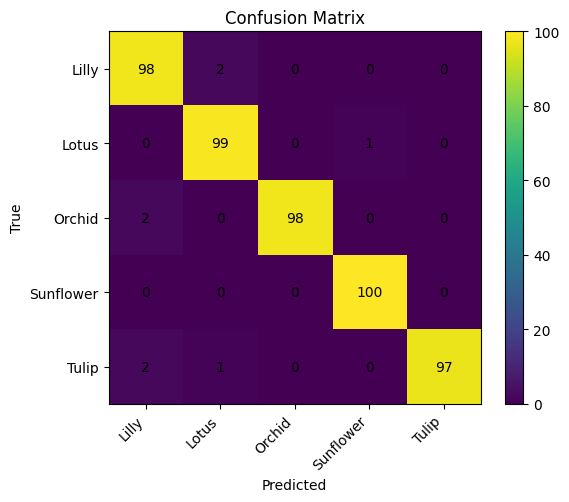

In [10]:

@torch.no_grad()
def evaluate_on_test(model, loader, class_names):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy().tolist())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = (all_preds == all_labels).mean()
    print(f"Test Accuracy: {acc:.3f}")

    if SKLEARN_OK:
        print('\nClassification Report:')
        print(classification_report(all_labels, all_preds, target_names=class_names))

        cm = confusion_matrix(all_labels, all_preds)
        import matplotlib.pyplot as plt
        plt.figure(figsize=(6,5))
        plt.imshow(cm, interpolation='nearest')
        plt.title('Confusion Matrix')
        plt.colorbar()
        tick_marks = np.arange(len(class_names))
        plt.xticks(tick_marks, class_names, rotation=45, ha='right')
        plt.yticks(tick_marks, class_names)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, cm[i, j], ha='center', va='center')
        plt.tight_layout()
        plt.show()
    else:
        print('(Install scikit-learn to see a classification report and confusion matrix.)')

evaluate_on_test(model, test_loader, CLASS_NAMES)  # call after training



### 5.1 Qualitative check: show a few predictions


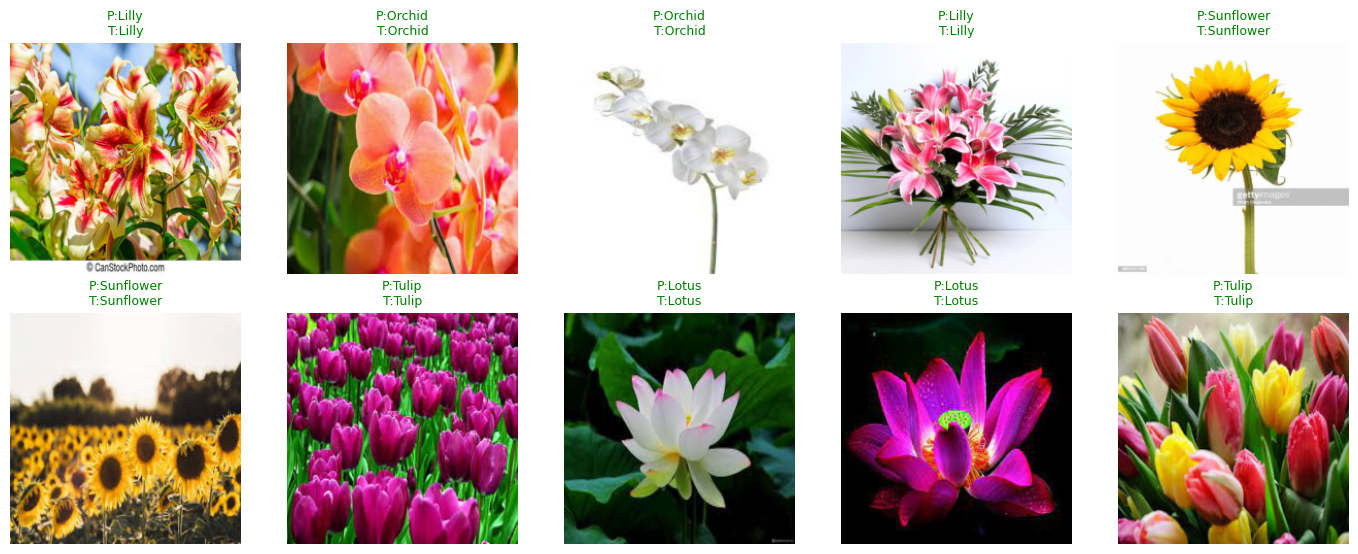

In [17]:

# ---- Visualize a few predictions ----
import math, random
def denormalize(img_tensor, mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)):
    if isinstance(mean, tuple): mean = torch.tensor(mean, device=img_tensor.device).view(3,1,1)
    if isinstance(std, tuple):  std  = torch.tensor(std,  device=img_tensor.device).view(3,1,1)
    return (img_tensor * std + mean).clamp(0,1)

@torch.no_grad()
def show_predictions_balanced(model, dataset, class_names, k_per_class=2, max_total=12):
    model.eval()
    targets = dataset.targets if hasattr(dataset, "targets") else [y for _, y in dataset]
    per_class = {c: [] for c in range(len(class_names))}
    for idx, y in enumerate(targets):
        per_class[int(y)].append(idx)

    chosen = []
    for c in range(len(class_names)):
        pool = per_class[c]
        if pool:
            k = min(k_per_class, len(pool))
            chosen += random.sample(pool, k)
    random.shuffle(chosen)
    chosen = chosen[:max_total]

    imgs, labels = [], []
    for i in chosen:
        img, y = dataset[i]
        imgs.append(img); labels.append(y)
    if not imgs:
        print("No images sampled. Check dataset path.");
    else:
        batch = torch.stack(imgs).to(DEVICE)
        labels = torch.tensor(labels, device=DEVICE)
        preds = model(batch).argmax(1)

        n = len(imgs); cols = min(5, n); rows = math.ceil(n/cols)
        plt.figure(figsize=(2.8*cols, 2.8*rows))
        for i in range(n):
            plt.subplot(rows, cols, i+1)
            disp = denormalize(batch[i].cpu()).permute(1,2,0)
            p, t = class_names[preds[i].item()], class_names[labels[i].item()]
            plt.imshow(disp); plt.axis("off")
            plt.title(f"P:{p}\nT:{t}", fontsize=9, color=("green" if p==t else "red"))
        plt.tight_layout(); plt.show()

show_predictions_balanced(model, test_ds, CLASS_NAMES, k_per_class=2, max_total=20)



## 6) Save & Load the Best Model


In [18]:

BEST_PATH = "vit_flowers_best.pth"
torch.save(model.state_dict(), BEST_PATH)  # save after training
print("Saved:", BEST_PATH)

# To load later:
# model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
# model.heads.head = nn.Linear(model.heads.head.in_features, NUM_CLASSES)
# model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
# model.to(DEVICE)
# model.eval()


Saved: vit_flowers_best.pth



## 7) Exercises (for deeper understanding)
1. **Freeze backbone** (`FREEZE_BACKBONE=True`) and compare training time & accuracy to full fine-tuning.
2. Try a different **optimizer** (SGD with momentum) or **scheduler** (CosineAnnealingLR).
3. Reduce augmentation to see **overfitting** on the training set—then add regularization (dropout/weight decay).
4. Replace `vit_b_16` with a smaller or larger ViT (if available in your `torchvision` version) and compare performance/parameters.
5. (Advanced) Read about **interpolating positional embeddings** to support non‑224 or rectangular inputs (e.g., 256×192); discuss pros/cons.

---

## 8) Key Takeaways
- **Transformers** use self-attention to model relationships between tokens.
- **ViT** treats image patches as tokens; with transfer learning it performs strongly on many vision tasks.
- **CNN vs ViT**: CNNs imprint inductive biases (great for small data), ViTs bring global attention (great when pretrained or with more data).


### What’s next?
- In the **next practical** we move from classification to **Object Detection**.
---

📝 This practical was designed by **Dr. Zaid Al-Huda** to give you hands-on with Vision Transformer, a quick refresher on Transformer self-attention (Q/K/V), then ViT’s patch embeddings, class token, and positional encodings.
